# Feature Importance Analysis

Understand which features matter most for predicting crop yield.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
df = pd.read_csv("./data/final_merged_data_rain_plus_crop_yield.csv")

X = df.drop(columns=["Yield", "Production", "Area"])
y = df["Yield"]

for col in ["District", "Crop", "Season"]:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
r2 = model.score(X_test, y_test)
print(f"Model R2: {r2:.4f}")

Model R2: 0.9877


## 1. Random Forest — Built-in Feature Importance (MDI)

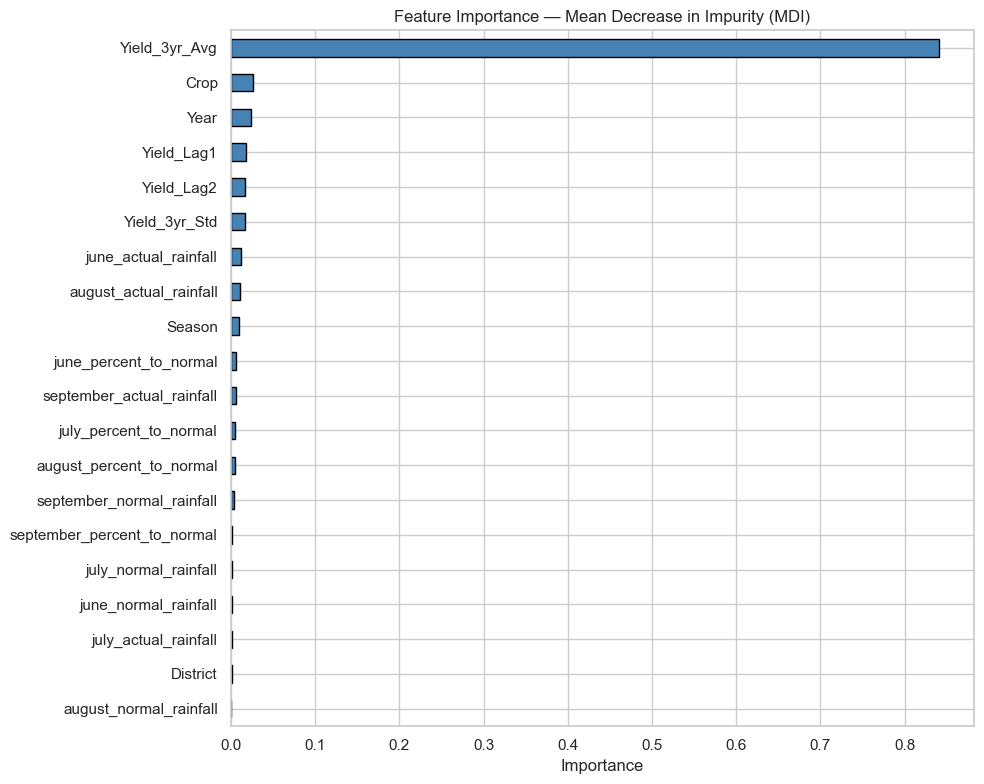


Top 10 features:
Yield_3yr_Avg             0.840534
Crop                      0.026356
Year                      0.023377
Yield_Lag1                0.017293
Yield_Lag2                0.016645
Yield_3yr_Std             0.015967
june_actual_rainfall      0.012160
august_actual_rainfall    0.010202
Season                    0.009609
june_percent_to_normal    0.005412
dtype: float64


In [3]:
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feat_imp.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance — Mean Decrease in Impurity (MDI)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(feat_imp.sort_values(ascending=False).head(10))

## 2. Permutation Importance

More reliable than MDI — measures how much the score drops when a feature is randomly shuffled.

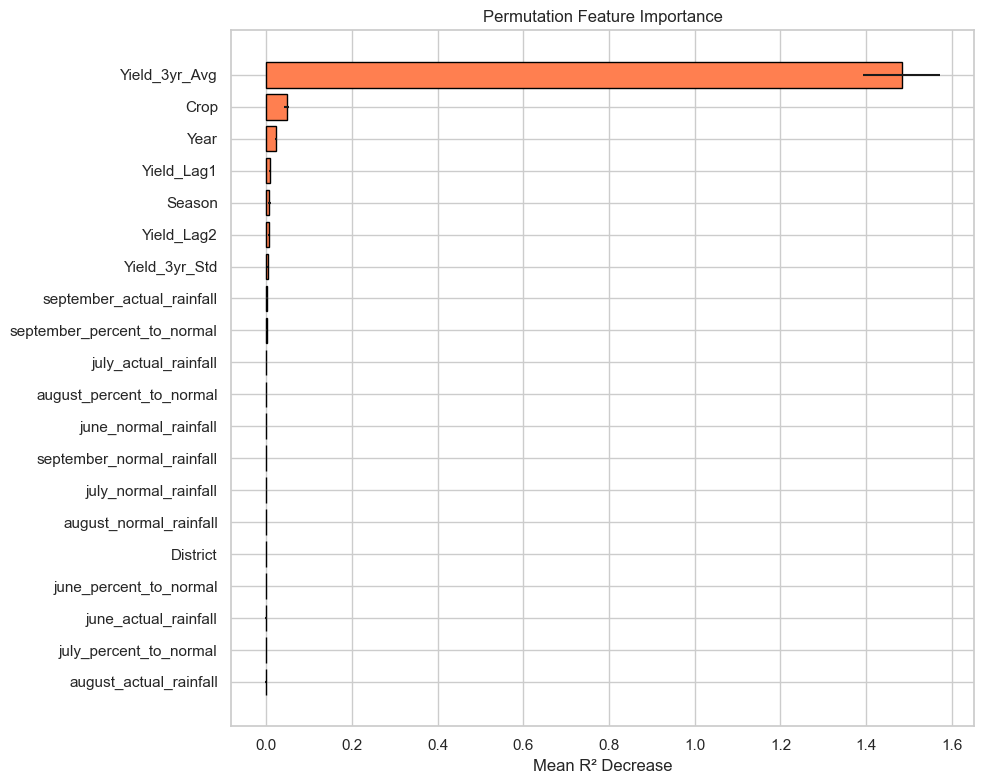

In [4]:
perm_imp = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

perm_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': perm_imp.importances_mean,
    'importance_std': perm_imp.importances_std
}).sort_values('importance_mean', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(perm_df['feature'], perm_df['importance_mean'], xerr=perm_df['importance_std'], color='coral', edgecolor='black')
plt.title('Permutation Feature Importance')
plt.xlabel('Mean R² Decrease')
plt.tight_layout()
plt.show()

## 3. Feature Importance Comparison — MDI vs Permutation

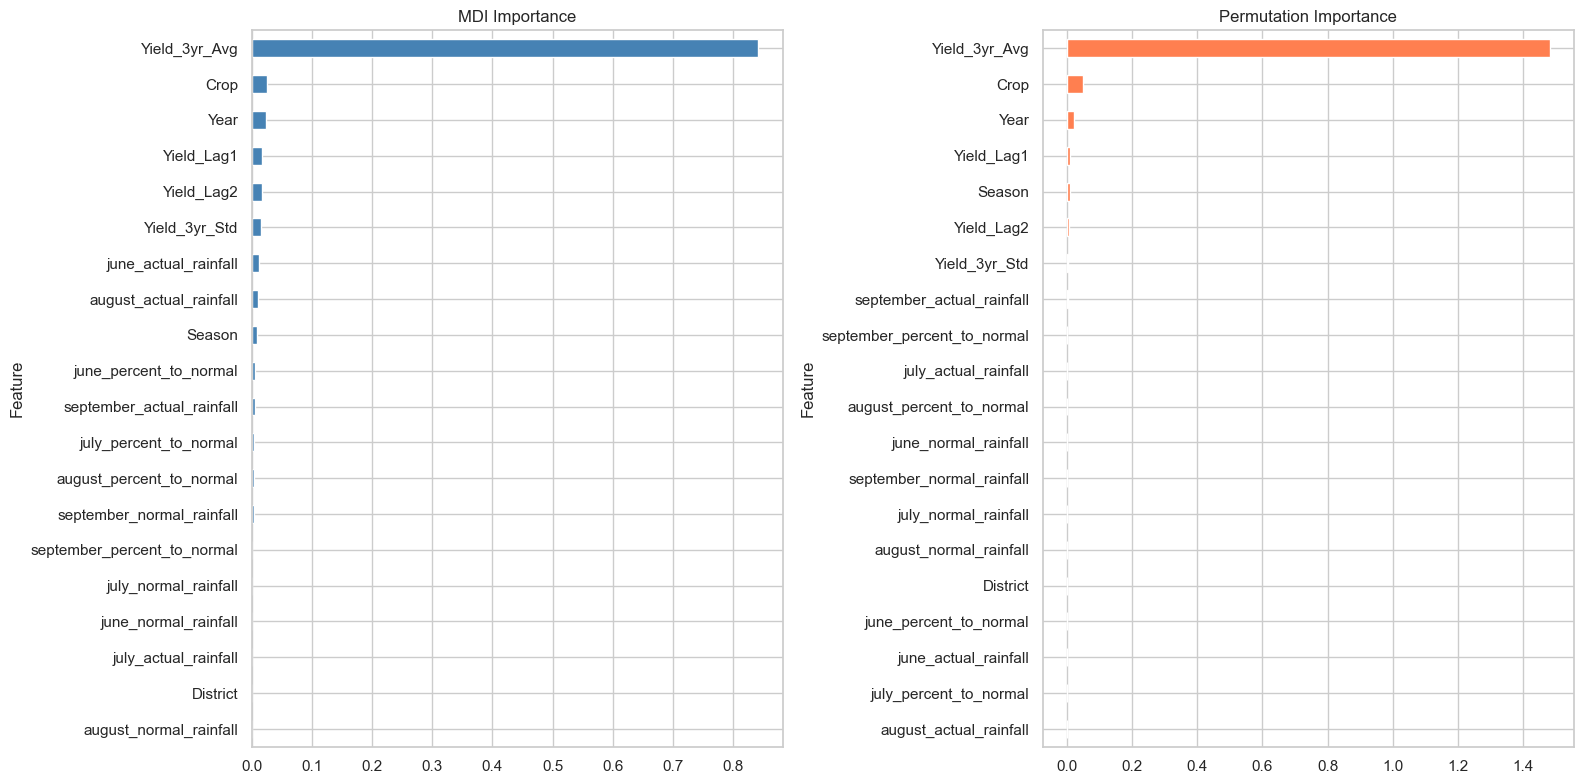

In [5]:
comparison = pd.DataFrame({
    'Feature': X.columns,
    'MDI': model.feature_importances_,
    'Permutation': perm_imp.importances_mean
}).sort_values('MDI', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

comparison.sort_values('MDI', ascending=True).plot(
    x='Feature', y='MDI', kind='barh', ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('MDI Importance')

comparison.sort_values('Permutation', ascending=True).plot(
    x='Feature', y='Permutation', kind='barh', ax=axes[1], color='coral', legend=False)
axes[1].set_title('Permutation Importance')

plt.tight_layout()
plt.show()

## 4. SHAP Analysis (Optional)

⚠️ **SHAP is computationally expensive.** Uncomment the cells below only if you have sufficient RAM/compute.

In [6]:
# Uncomment below to run SHAP analysis:
# 
# import shap
# 
# explainer = shap.TreeExplainer(model)
# X_sample = X_test.sample(500, random_state=42)
# shap_values = explainer.shap_values(X_sample)
# 
# # Summary plot
# shap.summary_plot(shap_values, X_sample)
# 
# # Dependence plots for rainfall features
# shap.dependence_plot("june_actual_rainfall", shap_values, X_sample)
# shap.dependence_plot("july_actual_rainfall", shap_values, X_sample)

## Summary

- **MDI** shows how much each feature contributes to reducing impurity in the random forest trees
- **Permutation importance** is more reliable — it measures actual predictive impact
- If lag features dominate, it means past yield is the strongest predictor (expected in time-series)
- Rainfall features show how weather affects crop yield beyond historical trends